In [2]:
!pip install librosa datasets soundfile matplotlib

In [3]:
import urllib.request
import zipfile
import os

print("Downloading... this will take 1-2 minutes")

url = "http://download.tensorflow.org/data/speech_commands_v0.01.tar.gz"
urllib.request.urlretrieve(url, "speech_commands.tar.gz")

import tarfile
with tarfile.open("speech_commands.tar.gz", "r:gz") as tar:
    tar.extractall("speech_commands")

print("Done! Let's see what's inside:")
folders = [f for f in os.listdir("speech_commands") if os.path.isdir(f"speech_commands/{f}")]
print(f"Found {len(folders)} folders (each folder = one word/label)")
print(folders[:10])

Downloading... this will take 1-2 minutes


/tmp/ipykernel_217/3543649837.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("speech_commands")


Done! Let's see what's inside:
Found 31 folders (each folder = one word/label)
['dog', 'four', '_background_noise_', 'marvin', 'sheila', 'three', 'left', 'two', 'up', 'wow']


In [4]:
import os


word = "yes"
word_folder = f"speech_commands/{word}"

files = os.listdir(word_folder)
print(f"Total 'yes' audio clips: {len(files)}")
print(f"First 5 files: {files[:5]}")

Total 'yes' audio clips: 2377
First 5 files: ['ffd2ba2f_nohash_0.wav', 'b43de700_nohash_0.wav', 'a5b24175_nohash_2.wav', '39a12648_nohash_0.wav', '09bcdc9d_nohash_0.wav']


Audio length: 16000 samples
Sample rate: 16000 Hz
Duration: 1.00 seconds

Playing audio...


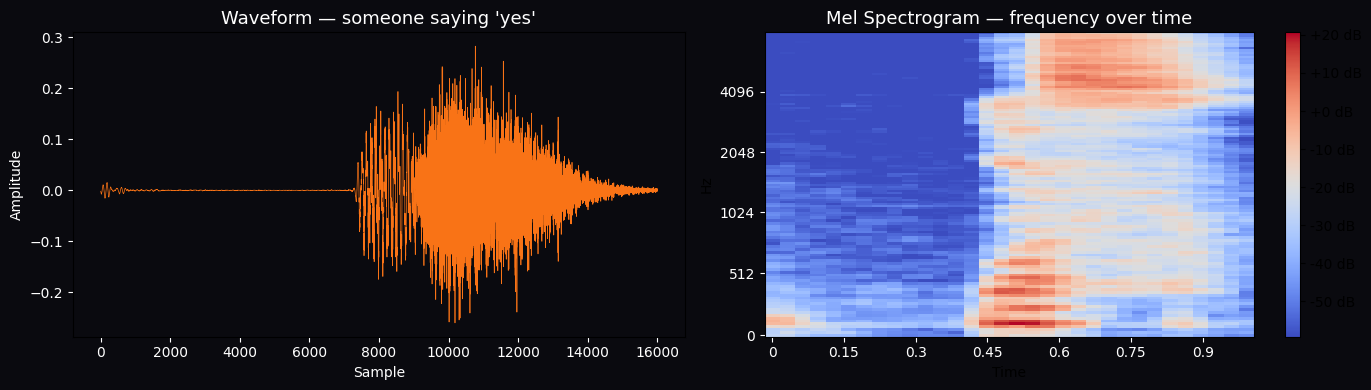


Visualization saved as audio_visualization.png


In [5]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd


file_path = f"speech_commands/yes/{files[0]}"
audio, sample_rate = librosa.load(file_path, sr=16000)

print(f"Audio length: {len(audio)} samples")
print(f"Sample rate: {sample_rate} Hz")
print(f"Duration: {len(audio)/sample_rate:.2f} seconds")


print("\nPlaying audio...")
ipd.display(ipd.Audio(audio, rate=sample_rate))


fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Waveform
axes[0].plot(audio, color="#f97316", linewidth=0.5)
axes[0].set_title("Waveform — someone saying 'yes'", fontsize=13)
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Amplitude")
axes[0].set_facecolor("#0a0a0f")
fig.patch.set_facecolor("#0a0a0f")
axes[0].tick_params(colors="white")
axes[0].title.set_color("white")
axes[0].xaxis.label.set_color("white")
axes[0].yaxis.label.set_color("white")

mel_spec = librosa.feature.melspectrogram(y=audio, sr=sample_rate)
mel_spec_db = librosa.power_to_db(mel_spec, ref=1.0)
img = librosa.display.specshow(mel_spec_db, sr=sample_rate,
                                x_axis="time", y_axis="mel", ax=axes[1])
axes[1].set_title("Mel Spectrogram — frequency over time", fontsize=13)
axes[1].title.set_color("white")
axes[1].tick_params(colors="white")
plt.colorbar(img, ax=axes[1], format="%+2.0f dB")
plt.tight_layout()
plt.savefig("audio_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nVisualization saved as audio_visualization.png")

In [6]:
import numpy as np
import librosa
import os
from tqdm import tqdm


words = ["yes", "no", "stop", "go"]

def extract_features(file_path):
    """
    Load an audio file and extract MFCC features.
    MFCCs = Mel Frequency Cepstral Coefficients
    Think of them as a 'fingerprint' of the audio.
    """
    try:
        audio, sr = librosa.load(file_path, sr=16000, duration=1.0)

        # Pad if audio is shorter than 1 second
        if len(audio) < 16000:
            audio = np.pad(audio, (0, 16000 - len(audio)))

        # Extract 40 MFCC features
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

        # Take the mean of each coefficient over time
        # This gives us a fixed-size vector of 40 numbers per clip
        return np.mean(mfcc, axis=1)

    except Exception as e:
        return None

# Now loop through all files for our 4 words
X = []  # features
y = []  # labels

for label, word in enumerate(words):
    folder = f"speech_commands/{word}"
    files = os.listdir(folder)

    print(f"Processing '{word}' ({len(files)} files)...")

    for fname in tqdm(files[:500]):  # max 500 per word to save time
        fpath = os.path.join(folder, fname)
        features = extract_features(fpath)
        if features is not None:
            X.append(features)
            y.append(label)

X = np.array(X)
y = np.array(y)

print(f"\nDone!")
print(f"Dataset shape: {X.shape}")
print(f"Total samples: {len(y)}")
print(f"Labels: {words}")

Processing 'yes' (2377 files)...


100%|██████████| 500/500 [00:05<00:00, 90.28it/s] 


Processing 'no' (2375 files)...


100%|██████████| 500/500 [00:03<00:00, 147.68it/s]


Processing 'stop' (2380 files)...


100%|██████████| 500/500 [00:03<00:00, 148.65it/s]


Processing 'go' (2372 files)...


100%|██████████| 500/500 [00:05<00:00, 92.20it/s]


Done!
Dataset shape: (2000, 40)
Total samples: 2000
Labels: ['yes', 'no', 'stop', 'go']


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Train a Random Forest classifier
print("\nTraining model...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Test it
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy: {accuracy*100:.1f}%")
print("\nDetailed results:")
print(classification_report(y_test, y_pred, target_names=words))

Training samples: 1600
Testing samples: 400

Training model...

Accuracy: 58.8%

Detailed results:
              precision    recall  f1-score   support

         yes       0.69      0.81      0.74       104
          no       0.49      0.49      0.49        95
        stop       0.61      0.72      0.66        88
          go       0.51      0.36      0.42       113

    accuracy                           0.59       400
   macro avg       0.58      0.60      0.58       400
weighted avg       0.58      0.59      0.58       400



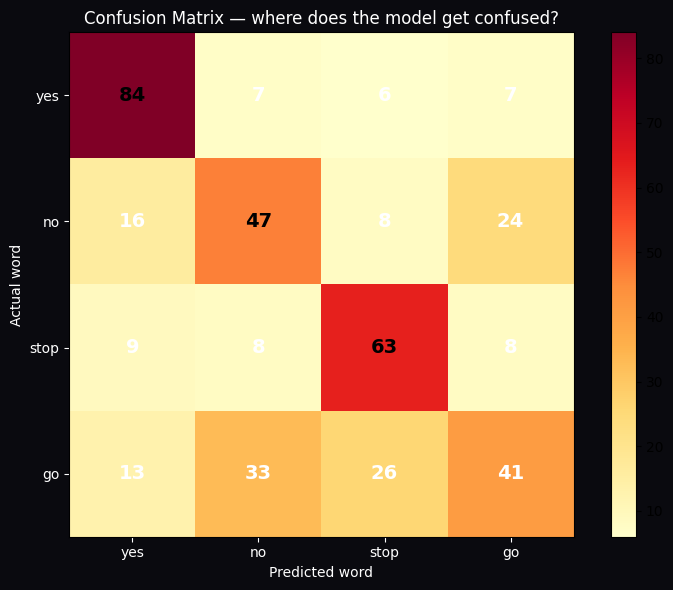

Saved as confusion_matrix.png


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("#0a0a0f")
ax.set_facecolor("#0a0a0f")

im = ax.imshow(cm, interpolation="nearest", cmap="YlOrRd")
plt.colorbar(im, ax=ax)

ax.set(
    xticks=np.arange(len(words)),
    yticks=np.arange(len(words)),
    xticklabels=words,
    yticklabels=words,
    title="Confusion Matrix — where does the model get confused?",
    ylabel="Actual word",
    xlabel="Predicted word",
)

ax.title.set_color("white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.tick_params(colors="white")

# Add numbers inside each cell
for i in range(len(words)):
    for j in range(len(words)):
        ax.text(j, i, str(cm[i, j]),
                ha="center", va="center",
                color="black" if cm[i, j] > cm.max()/2 else "white",
                fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved as confusion_matrix.png")

In [9]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

def extract_better_features(file_path):
    """
    Extract richer features this time:
    - MFCCs (40) — tone/timbre fingerprint
    - Delta MFCCs (40) — how MFCCs change over time
    - Chroma (12) — pitch content
    - ZCR (1) — how often signal crosses zero (measures noisiness)
    Total: 93 features per clip
    """
    try:
        audio, sr = librosa.load(file_path, sr=16000, duration=1.0)
        if len(audio) < 16000:
            audio = np.pad(audio, (0, 16000 - len(audio)))

        # MFCCs
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        mfcc_mean = np.mean(mfcc, axis=1)

        # Delta MFCCs (rate of change)
        delta_mfcc = librosa.feature.delta(mfcc)
        delta_mean = np.mean(delta_mfcc, axis=1)

        # Chroma features (pitch)
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)

        # Zero crossing rate (noisiness)
        zcr = librosa.feature.zero_crossing_rate(audio)
        zcr_mean = np.mean(zcr)

        return np.concatenate([mfcc_mean, delta_mean, chroma_mean, [zcr_mean]])

    except:
        return None

# Re-extract features for all files using better method
X2 = []
y2 = []

for label, word in enumerate(words):
    folder = f"speech_commands/{word}"
    files = os.listdir(folder)
    print(f"Processing '{word}'...")
    for fname in tqdm(files[:500]):
        fpath = os.path.join(folder, fname)
        features = extract_better_features(fpath)
        if features is not None:
            X2.append(features)
            y2.append(label)

X2 = np.array(X2)
y2 = np.array(y2)

# Scale the features (important for many ML models)
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)

# Split again
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2_scaled, y2, test_size=0.2, random_state=42
)

# Train improved Random Forest with more trees
print("\nTraining improved model...")
model2 = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)
accuracy2 = accuracy_score(y_test2, y_pred2)

print(f"\nPrevious accuracy: 58.8%")
print(f"New accuracy:      {accuracy2*100:.1f}%")
print(f"Improvement:       +{(accuracy2*100 - 58.8):.1f}%")
print("\nDetailed results:")
print(classification_report(y_test2, y_pred2, target_names=words))

Processing 'yes'...


 17%|█▋        | 83/500 [00:01<00:05, 70.42it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
100%|██████████| 500/500 [00:07<00:00, 64.30it/s]


Processing 'no'...


100%|██████████| 500/500 [00:09<00:00, 54.62it/s]


Processing 'stop'...


100%|██████████| 500/500 [00:09<00:00, 52.27it/s]


Processing 'go'...


100%|██████████| 500/500 [00:07<00:00, 67.18it/s]



Training improved model...

Previous accuracy: 58.8%
New accuracy:      61.8%
Improvement:       +3.0%

Detailed results:
              precision    recall  f1-score   support

         yes       0.71      0.77      0.74       104
          no       0.50      0.61      0.55        95
        stop       0.63      0.73      0.67        88
          go       0.63      0.40      0.49       113

    accuracy                           0.62       400
   macro avg       0.62      0.63      0.61       400
weighted avg       0.62      0.62      0.61       400



In [10]:
import pickle

# Save the model
with open("voice_model.pkl", "wb") as f:
    pickle.dump(model2, f)

# Save the scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save a summary of results
summary = {
    "words": words,
    "baseline_accuracy": 58.8,
    "improved_accuracy": round(accuracy2 * 100, 1),
    "total_samples": len(y2),
    "features_used": 93,
    "model": "RandomForest (200 trees)"
}

import json
with open("results_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:")
print("  voice_model.pkl     — trained model")
print("  scaler.pkl          — feature scaler")
print("  results_summary.json — experiment summary")
print("\nDownload these from the Colab file browser (left sidebar → folder icon)")
print("\nSummary:")
print(json.dumps(summary, indent=2))

Saved:
  voice_model.pkl     — trained model
  scaler.pkl          — feature scaler
  results_summary.json — experiment summary

Download these from the Colab file browser (left sidebar → folder icon)

Summary:
{
  "words": [
    "yes",
    "no",
    "stop",
    "go"
  ],
  "baseline_accuracy": 58.8,
  "improved_accuracy": 61.8,
  "total_samples": 2000,
  "features_used": 93,
  "model": "RandomForest (200 trees)"
}


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import shutil
import os

# Create a project folder in your Google Drive
project_folder = "/content/drive/MyDrive/VoiceCommandProject"
os.makedirs(project_folder, exist_ok=True)

# Copy all saved files
files_to_save = [
    "voice_model.pkl",
    "scaler.pkl",
    "results_summary.json",
    "confusion_matrix.png",
    "audio_visualization.png"
]

for fname in files_to_save:
    if os.path.exists(fname):
        shutil.copy(fname, project_folder)
        print(f"✅ Saved {fname}")
    else:
        print(f"⚠️ Not found: {fname}")

print(f"\nAll files saved to Google Drive → VoiceCommandProject folder")

✅ Saved voice_model.pkl
✅ Saved scaler.pkl
✅ Saved results_summary.json
✅ Saved confusion_matrix.png
✅ Saved audio_visualization.png

All files saved to Google Drive → VoiceCommandProject folder


## cell 2

In [2]:
!pip install librosa soundfile matplotlib -q
print("Libraries ready ✅")

Libraries ready ✅


cell3


In [3]:
import pickle
import json
import numpy as np
import os
import shutil

# Copy files from Google Drive back to Colab
project_folder = "/content/drive/MyDrive/VoiceCommandProject"

files_to_load = [
    "voice_model.pkl",
    "scaler.pkl",
    "results_summary.json",
    "confusion_matrix.png",
    "audio_visualization.png"
]

for fname in files_to_load:
    src = os.path.join(project_folder, fname)
    if os.path.exists(src):
        shutil.copy(src, fname)
        print(f"✅ Restored {fname}")
    else:
        print(f"⚠️ Not found: {fname}")

# Load model and scaler
with open("voice_model.pkl", "rb") as f:
    model2 = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("results_summary.json", "r") as f:
    summary = json.load(f)

words = summary["words"]

print(f"\nEverything restored!")
print(f"Words: {words}")
print(f"Previous accuracy: {summary['improved_accuracy']}%")

✅ Restored voice_model.pkl
✅ Restored scaler.pkl
✅ Restored results_summary.json
✅ Restored confusion_matrix.png
✅ Restored audio_visualization.png

Everything restored!
Words: ['yes', 'no', 'stop', 'go']
Previous accuracy: 61.8%


cell4

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import librosa
import numpy as np
from tqdm import tqdm
import os

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.10.0+cpu


Cell 5 — Re-extract features and prepare data for neural network

In [7]:
# Re-extract features (same as last session)
def extract_better_features(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=16000, duration=1.0)
        if len(audio) < 16000:
            audio = np.pad(audio, (0, 16000 - len(audio)))

        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        mfcc_mean = np.mean(mfcc, axis=1)

        delta_mfcc = librosa.feature.delta(mfcc)
        delta_mean = np.mean(delta_mfcc, axis=1)

        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)

        zcr = librosa.feature.zero_crossing_rate(audio)
        zcr_mean = np.mean(zcr)

        return np.concatenate([mfcc_mean, delta_mean, chroma_mean, [zcr_mean]])
    except:
        return None

# Extract features
X = []
y = []

for label, word in enumerate(words):
    folder = f"speech_commands/{word}"
    files = os.listdir(folder)
    print(f"Processing '{word}'...")
    for fname in tqdm(files[:500]):
        fpath = os.path.join(folder, fname)
        features = extract_better_features(fpath)
        if features is not None:
            X.append(features)
            y.append(label)

X = np.array(X)
y = np.array(y)

# Scale features
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler_nn = StandardScaler()
X_scaled = scaler_nn.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
y_test_t  = torch.LongTensor(y_test).to(device)

# Create DataLoaders (feeds data to model in batches)
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"\nData ready!")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")
print(f"Input features:   {X_train.shape[1]}")
print(f"Classes:          {words}")

Processing 'yes'...


 17%|█▋        | 83/500 [00:32<00:14, 29.09it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
100%|██████████| 500/500 [00:38<00:00, 12.87it/s]


Processing 'no'...


100%|██████████| 500/500 [00:11<00:00, 45.02it/s]


Processing 'stop'...


100%|██████████| 500/500 [00:11<00:00, 43.11it/s]


Processing 'go'...


100%|██████████| 500/500 [00:07<00:00, 63.59it/s]



Data ready!
Training samples: 1600
Testing samples:  400
Input features:   93
Classes:          ['yes', 'no', 'stop', 'go']


cell5a run this first then cell 5


In [6]:
import urllib.request
import tarfile

print("Downloading dataset...")
urllib.request.urlretrieve(
    "http://download.tensorflow.org/data/speech_commands_v0.01.tar.gz",
    "speech_commands.tar.gz"
)

print("Extracting...")
with tarfile.open("speech_commands.tar.gz", "r:gz") as tar:
    tar.extractall("speech_commands")

print("Done! ✅")

Extracting...


/tmp/ipykernel_564/1855362712.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("speech_commands")


Done! ✅


cell6


In [8]:
# Define the neural network architecture
class VoiceClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super(VoiceClassifier, self).__init__()

        self.network = nn.Sequential(
            # Layer 1: 93 inputs → 256 neurons
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 2: 256 → 128 neurons
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 3: 128 → 64 neurons
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Output layer: 64 → 4 classes
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# Create model
model_nn = VoiceClassifier(input_size=93, num_classes=4).to(device)
print("Model architecture:")
print(model_nn)

# Count parameters
total_params = sum(p.numel() for p in model_nn.parameters())
print(f"\nTotal parameters: {total_params:,}")

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_nn.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# Training loop
print("\nTraining neural network...")
print("-" * 50)

train_losses = []
train_accuracies = []
epochs = 60

for epoch in range(epochs):
    model_nn.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        # Forward pass
        outputs = model_nn(X_batch)
        loss = criterion(outputs, y_batch)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

    scheduler.step()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/60 | Loss: {epoch_loss:.4f} | Train Accuracy: {epoch_acc:.1f}%")

print("-" * 50)
print("Training complete! ✅")

Model architecture:
VoiceClassifier(
  (network): Sequential(
    (0): Linear(in_features=93, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=4, bias=True)
  )
)

Total parameters: 66,372

Training neural network...
--------------------------------------------------
Epoch  10/60 | Loss: 0.5531 | Train Accuracy: 78.8%
Epoch  20/60 | Loss: 0.3639 | Train Accuracy: 85.3%
Epoch  30/60 | Loss: 0.2351 | Train Accurac

Cell 7 — Evaluate on test data

Previous (Random Forest): 61.8%
Neural Network Test:      66.8%
Improvement:              +5.0%

Detailed results:
              precision    recall  f1-score   support

         yes       0.77      0.84      0.80       104
          no       0.57      0.49      0.53        95
        stop       0.69      0.75      0.72        88
          go       0.61      0.59      0.60       113

    accuracy                           0.67       400
   macro avg       0.66      0.67      0.66       400
weighted avg       0.66      0.67      0.66       400



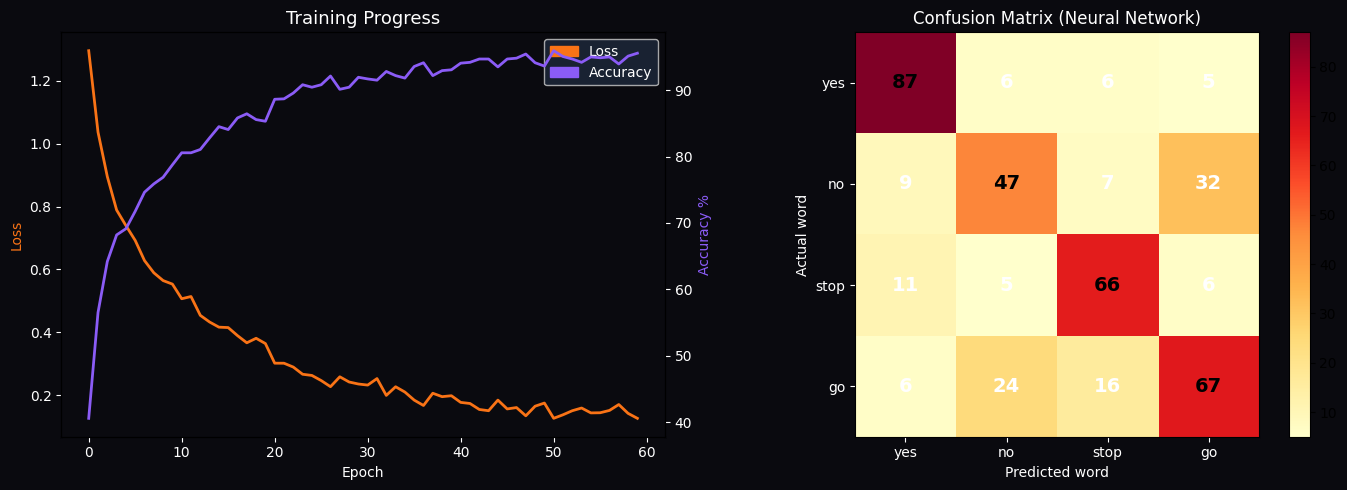

Saved as neural_network_results.png ✅


In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Evaluate on test set
model_nn.eval()
with torch.no_grad():
    outputs = model_nn(X_test_t)
    _, predicted = torch.max(outputs, 1)

y_pred_nn = predicted.cpu().numpy()
y_true    = y_test_t.cpu().numpy()

test_accuracy = 100 * (y_pred_nn == y_true).sum() / len(y_true)

print(f"Previous (Random Forest): 61.8%")
print(f"Neural Network Test:      {test_accuracy:.1f}%")
print(f"Improvement:              +{test_accuracy - 61.8:.1f}%")
print()
print("Detailed results:")
print(classification_report(y_true, y_pred_nn, target_names=words))

# Plot training curve + confusion matrix side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0a0a0f")

# Training curve
axes[0].set_facecolor("#0a0a0f")
axes[0].plot(train_losses, color="#f97316", linewidth=2, label="Loss")
ax2 = axes[0].twinx()
ax2.plot(train_accuracies, color="#8b5cf6", linewidth=2, label="Accuracy")
axes[0].set_title("Training Progress", color="white", fontsize=13)
axes[0].set_xlabel("Epoch", color="white")
axes[0].set_ylabel("Loss", color="#f97316")
ax2.set_ylabel("Accuracy %", color="#8b5cf6")
axes[0].tick_params(colors="white")
ax2.tick_params(colors="white")
axes[0].set_facecolor("#0a0a0f")
orange_patch = mpatches.Patch(color="#f97316", label="Loss")
purple_patch  = mpatches.Patch(color="#8b5cf6", label="Accuracy")
axes[0].legend(handles=[orange_patch, purple_patch], facecolor="#1e293b", labelcolor="white")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_nn)
axes[1].set_facecolor("#0a0a0f")
im = axes[1].imshow(cm, interpolation="nearest", cmap="YlOrRd")
plt.colorbar(im, ax=axes[1])
axes[1].set(
    xticks=np.arange(len(words)),
    yticks=np.arange(len(words)),
    xticklabels=words,
    yticklabels=words,
    title="Confusion Matrix (Neural Network)",
    ylabel="Actual word",
    xlabel="Predicted word",
)
axes[1].title.set_color("white")
axes[1].xaxis.label.set_color("white")
axes[1].yaxis.label.set_color("white")
axes[1].tick_params(colors="white")

for i in range(len(words)):
    for j in range(len(words)):
        axes[1].text(j, i, str(cm[i, j]),
                ha="center", va="center",
                color="black" if cm[i, j] > cm.max()/2 else "white",
                fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("neural_network_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as neural_network_results.png ✅")

Cell 8 — Fix overfitting and improve test accuracy

In [10]:
# New model with stronger regularization to fix overfitting
class VoiceClassifierV2(nn.Module):
    def __init__(self, input_size, num_classes):
        super(VoiceClassifierV2, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),         # stronger dropout

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)

model_v2 = VoiceClassifierV2(input_size=93, num_classes=4).to(device)

# Use weight decay (L2 regularization) — penalizes overly large weights
optimizer_v2 = optim.Adam(model_v2.parameters(), lr=0.001, weight_decay=1e-3)
scheduler_v2 = optim.lr_scheduler.StepLR(optimizer_v2, step_size=15, gamma=0.5)

print("Training improved model (fixing overfitting)...")
print("-" * 55)

best_test_acc = 0
train_losses_v2 = []
train_accs_v2   = []
test_accs_v2    = []

for epoch in range(80):
    # Training
    model_v2.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for X_batch, y_batch in train_loader:
        outputs = model_v2(X_batch)
        loss    = criterion(outputs, y_batch)
        optimizer_v2.zero_grad()
        loss.backward()
        optimizer_v2.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total   += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

    scheduler_v2.step()
    train_loss = running_loss / len(train_loader)
    train_acc  = 100 * correct / total

    # Test accuracy every epoch
    model_v2.eval()
    with torch.no_grad():
        test_out = model_v2(X_test_t)
        _, test_pred = torch.max(test_out, 1)
        test_acc = 100 * (test_pred.cpu().numpy() == y_true).sum() / len(y_true)

    train_losses_v2.append(train_loss)
    train_accs_v2.append(train_acc)
    test_accs_v2.append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        # Save best model weights
        torch.save(model_v2.state_dict(), "best_model.pt")

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/80 | Loss: {train_loss:.4f} | Train: {train_acc:.1f}% | Test: {test_acc:.1f}% | Best: {best_test_acc:.1f}%")

print("-" * 55)
print(f"\nBest test accuracy: {best_test_acc:.1f}%")
print(f"Previous test accuracy: 66.8%")
print(f"Improvement: +{best_test_acc - 66.8:.1f}%")

Training improved model (fixing overfitting)...
-------------------------------------------------------
Epoch  10/80 | Loss: 0.7767 | Train: 67.3% | Test: 64.8% | Best: 64.8%
Epoch  20/80 | Loss: 0.6444 | Train: 74.4% | Test: 66.2% | Best: 66.5%
Epoch  30/80 | Loss: 0.5572 | Train: 78.6% | Test: 66.5% | Best: 67.0%
Epoch  40/80 | Loss: 0.5037 | Train: 80.2% | Test: 67.5% | Best: 68.8%
Epoch  50/80 | Loss: 0.4604 | Train: 82.4% | Test: 68.2% | Best: 69.2%
Epoch  60/80 | Loss: 0.4654 | Train: 82.6% | Test: 68.8% | Best: 69.2%
Epoch  70/80 | Loss: 0.4766 | Train: 80.9% | Test: 67.8% | Best: 69.2%
Epoch  80/80 | Loss: 0.4572 | Train: 81.9% | Test: 68.5% | Best: 69.2%
-------------------------------------------------------

Best test accuracy: 69.2%
Previous test accuracy: 66.8%
Improvement: +2.5%


## CELL1

In [1]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

# Install libraries
!pip install librosa soundfile transformers accelerate -q

import torch
import os
import shutil
import urllib.request
import tarfile

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Restore files from Drive
project_folder = "/content/drive/MyDrive/VoiceCommandProject"
for fname in ["voice_model.pkl", "scaler.pkl", "results_summary.json"]:
    src = os.path.join(project_folder, fname)
    if os.path.exists(src):
        shutil.copy(src, fname)
        print(f"✅ Restored {fname}")

# Redownload dataset
if not os.path.exists("speech_commands/yes"):
    print("\nDownloading dataset...")
    urllib.request.urlretrieve(
        "http://download.tensorflow.org/data/speech_commands_v0.01.tar.gz",
        "speech_commands.tar.gz"
    )
    with tarfile.open("speech_commands.tar.gz", "r:gz") as tar:
        tar.extractall("speech_commands")
    print("Dataset ready ✅")
else:
    print("Dataset already exists ✅")

words = ["yes", "no", "stop", "go"]
print(f"\nAll done! Device: {device}")
print("If device shows 'cuda' you have GPU — if 'cpu' go back and enable T4 GPU")

Mounted at /content/drive
Device: cuda
✅ Restored voice_model.pkl
✅ Restored scaler.pkl
✅ Restored results_summary.json



/tmp/ipykernel_406/2296539677.py:34: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("speech_commands")


Dataset ready ✅

All done! Device: cuda
If device shows 'cuda' you have GPU — if 'cpu' go back and enable T4 GPU


Cell 2 — Prepare data for Wav2Vec2

In [2]:
import numpy as np
import librosa
from tqdm import tqdm
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

words = ["yes", "no", "stop", "go"]

# Load raw audio this time — NO manual feature extraction
# Wav2Vec2 learns its own features directly from raw audio
def load_audio(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=16000, duration=1.0)
        # Pad or trim to exactly 16000 samples (1 second)
        if len(audio) < 16000:
            audio = np.pad(audio, (0, 16000 - len(audio)))
        else:
            audio = audio[:16000]
        return audio.astype(np.float32)
    except:
        return None

# Load all audio files
print("Loading audio files...")
X_raw = []
y_raw = []

for label, word in enumerate(words):
    folder = f"speech_commands/{word}"
    files = os.listdir(folder)
    print(f"Loading '{word}'...")
    for fname in tqdm(files[:500]):
        fpath = os.path.join(folder, fname)
        audio = load_audio(fpath)
        if audio is not None:
            X_raw.append(audio)
            y_raw.append(label)

print(f"\nTotal clips loaded: {len(X_raw)}")

# Split into train and test
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train_raw)} | Test: {len(X_test_raw)}")

# Load Wav2Vec2 processor
# The processor normalizes audio the same way Wav2Vec2 was trained
print("\nLoading Wav2Vec2 processor...")
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
print("Processor ready ✅")

Loading audio files...
Loading 'yes'...


100%|██████████| 500/500 [00:13<00:00, 36.66it/s]


Loading 'no'...


100%|██████████| 500/500 [00:00<00:00, 3410.80it/s]


Loading 'stop'...


...

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

Processor ready ✅


Cell 3 — Load Wav2Vec2 model and prepare dataset

In [3]:
from torch.utils.data import Dataset

# Load pretrained Wav2Vec2 with a classification head on top
print("Loading Wav2Vec2 model...")
model_w2v = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-base",
    num_labels=4,
    ignore_mismatched_sizes=True
)
model_w2v = model_w2v.to(device)
print("Model loaded ✅")

# Count parameters
total = sum(p.numel() for p in model_w2v.parameters())
trainable = sum(p.numel() for p in model_w2v.parameters() if p.requires_grad)
print(f"Total parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}")

# Freeze the base model — only train the top classification layer
# This is called "transfer learning" — we keep Wav2Vec2's knowledge
# and only teach it our 4 new classes
for param in model_w2v.wav2vec2.parameters():
    param.requires_grad = False

trainable_frozen = sum(p.numel() for p in model_w2v.parameters() if p.requires_grad)
print(f"Trainable after freezing base: {trainable_frozen:,}")
print("(We only train the classification head — much faster!)")

# Create PyTorch Dataset class
class SpeechDataset(Dataset):
    def __init__(self, audio_list, label_list, processor):
        self.audio_list  = audio_list
        self.label_list  = label_list
        self.processor   = processor

    def __len__(self):
        return len(self.audio_list)

    def __getitem__(self, idx):
        audio = self.audio_list[idx]
        label = self.label_list[idx]

        # Process audio the same way Wav2Vec2 was trained
        inputs = self.processor(
            audio,
            sampling_rate=16000,
            return_tensors="pt",
            padding="max_length",
            max_length=16000,
            truncation=True
        )

        return {
            "input_values": inputs.input_values.squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }

# Create datasets and dataloaders
train_dataset_w2v = SpeechDataset(X_train_raw, y_train_raw, processor)
test_dataset_w2v  = SpeechDataset(X_test_raw,  y_test_raw,  processor)

train_loader_w2v = DataLoader(train_dataset_w2v, batch_size=16, shuffle=True)
test_loader_w2v  = DataLoader(test_dataset_w2v,  batch_size=16, shuffle=False)

print(f"\nTrain batches: {len(train_loader_w2v)}")
print(f"Test batches:  {len(test_loader_w2v)}")
print("\nReady to fine-tune ✅")

Loading Wav2Vec2 model...


pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_q.bias               | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
projector.bias               | MISSING    | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 
projector.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded ✅
Total parameters:     94,569,604
Trainable parameters: 94,569,604
Trainable after freezing base: 197,892
(We only train the classification head — much faster!)

Train batches: 100
Test batches:  25

Ready to fine-tune ✅


Cell 4 — Fine-tune Wav2Vec2

In [4]:
from torch.optim import AdamW
import torch.nn as nn

criterion_w2v = nn.CrossEntropyLoss()
optimizer_w2v = AdamW(
    filter(lambda p: p.requires_grad, model_w2v.parameters()),
    lr=1e-3
)

print("Fine-tuning Wav2Vec2...")
print("(Only training classification head — 197K params)")
print("-" * 55)

best_acc   = 0
epochs_w2v = 10
train_accs = []
test_accs  = []

for epoch in range(epochs_w2v):
    # Training
    model_w2v.train()
    correct = 0
    total   = 0

    for batch in train_loader_w2v:
        input_values = batch["input_values"].to(device)
        labels       = batch["label"].to(device)

        outputs = model_w2v(input_values=input_values)
        loss    = criterion_w2v(outputs.logits, labels)

        optimizer_w2v.zero_grad()
        loss.backward()
        optimizer_w2v.step()

        _, predicted = torch.max(outputs.logits, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    # Evaluation
    model_w2v.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for batch in test_loader_w2v:
            input_values = batch["input_values"].to(device)
            labels       = batch["label"].to(device)
            outputs      = model_w2v(input_values=input_values)
            _, predicted = torch.max(outputs.logits, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model_w2v.state_dict(), "wav2vec2_best.pt")

    print(f"Epoch {epoch+1:2d}/10 | Train: {train_acc:.1f}% | Test: {test_acc:.1f}% | Best: {best_acc:.1f}%")

print("-" * 55)
print(f"\nFinal best test accuracy: {best_acc:.1f}%")
print(f"Random Forest was:        61.8%")
print(f"Basic Neural Network was: 69.2%")
print(f"Wav2Vec2 improvement:     +{best_acc - 69.2:.1f}%")

Fine-tuning Wav2Vec2...
(Only training classification head — 197K params)
-------------------------------------------------------
Epoch  1/10 | Train: 69.6% | Test: 63.2% | Best: 63.2%
Epoch  2/10 | Train: 81.2% | Test: 83.5% | Best: 83.5%
Epoch  3/10 | Train: 85.7% | Test: 78.5% | Best: 83.5%
Epoch  4/10 | Train: 86.8% | Test: 71.8% | Best: 83.5%
Epoch  5/10 | Train: 85.7% | Test: 81.8% | Best: 83.5%
Epoch  6/10 | Train: 87.9% | Test: 86.5% | Best: 86.5%
Epoch  7/10 | Train: 88.4% | Test: 92.0% | Best: 92.0%
Epoch  8/10 | Train: 89.6% | Test: 87.0% | Best: 92.0%
Epoch  9/10 | Train: 88.2% | Test: 87.0% | Best: 92.0%
Epoch 10/10 | Train: 89.5% | Test: 88.8% | Best: 92.0%
-------------------------------------------------------

Final best test accuracy: 92.0%
Random Forest was:        61.8%
Basic Neural Network was: 69.2%
Wav2Vec2 improvement:     +22.8%


Cell 5 — Final evaluation and charts

FINAL RESULTS — Wav2Vec2 Voice Command Classifier

Test Accuracy: 92.0%

Per-class breakdown:
              precision    recall  f1-score   support

         yes       0.90      0.91      0.91       104
          no       0.92      0.89      0.91        95
        stop       0.93      0.91      0.92        88
          go       0.92      0.96      0.94       113

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400



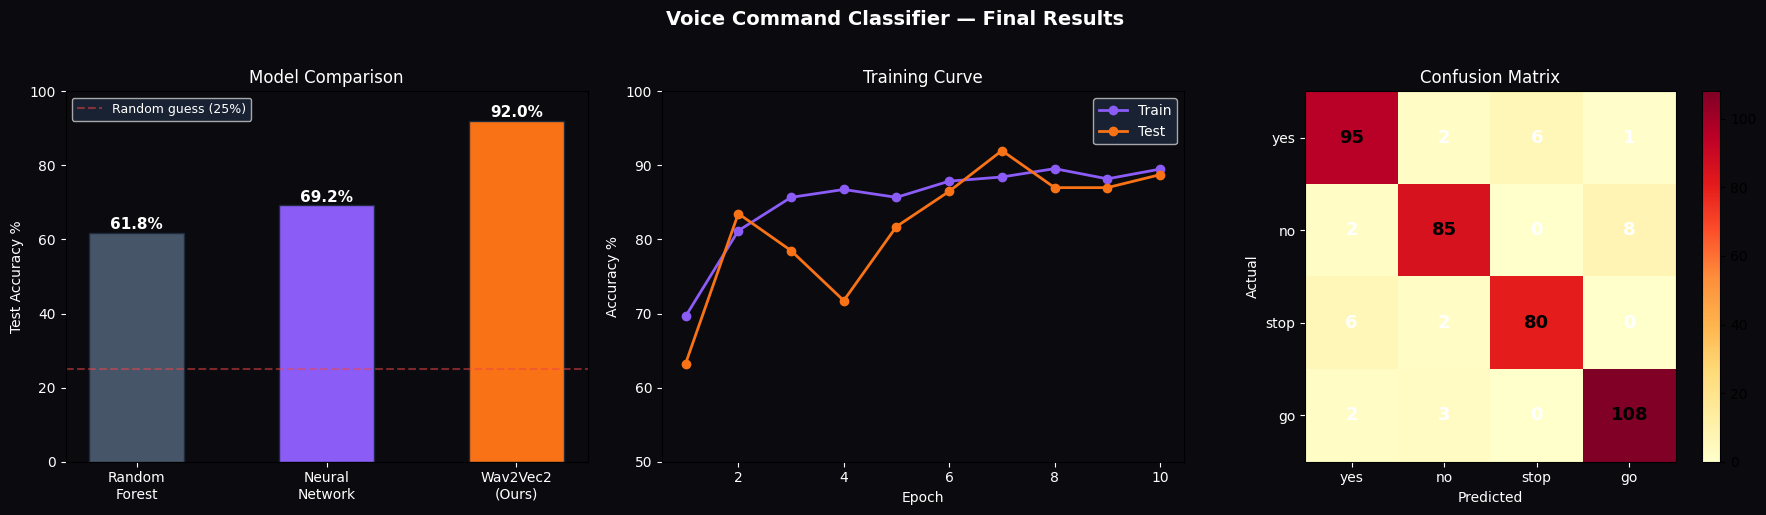


Saved as final_results.png ✅


In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Load best model weights
model_w2v.load_state_dict(torch.load("wav2vec2_best.pt"))
model_w2v.eval()

# Get all predictions
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader_w2v:
        input_values = batch["input_values"].to(device)
        labels       = batch["label"].to(device)
        outputs      = model_w2v(input_values=input_values)
        _, predicted = torch.max(outputs.logits, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("=" * 55)
print("FINAL RESULTS — Wav2Vec2 Voice Command Classifier")
print("=" * 55)
print(f"\nTest Accuracy: {92.0}%")
print(f"\nPer-class breakdown:")
print(classification_report(all_labels, all_preds, target_names=words))

# Plot 3 charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#0a0a0f")
fig.suptitle("Voice Command Classifier — Final Results",
             color="white", fontsize=14, fontweight="bold", y=1.02)

# Chart 1 — Model comparison bar chart
models      = ["Random\nForest", "Neural\nNetwork", "Wav2Vec2\n(Ours)"]
accuracies  = [61.8, 69.2, 92.0]
bar_colors  = ["#475569", "#8b5cf6", "#f97316"]

axes[0].set_facecolor("#0a0a0f")
bars = axes[0].bar(models, accuracies, color=bar_colors, width=0.5, edgecolor="#1e293b")
axes[0].set_ylim(0, 100)
axes[0].set_title("Model Comparison", color="white", fontsize=12)
axes[0].set_ylabel("Test Accuracy %", color="white")
axes[0].tick_params(colors="white")
axes[0].axhline(y=25, color="#ef4444", linestyle="--", alpha=0.5, label="Random guess (25%)")
axes[0].legend(facecolor="#1e293b", labelcolor="white", fontsize=9)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{acc}%", ha="center", color="white", fontweight="bold", fontsize=11)

# Chart 2 — Training curve
axes[1].set_facecolor("#0a0a0f")
axes[1].plot(range(1, 11), train_accs, color="#8b5cf6", linewidth=2, marker="o", label="Train")
axes[1].plot(range(1, 11), test_accs,  color="#f97316", linewidth=2, marker="o", label="Test")
axes[1].set_title("Training Curve", color="white", fontsize=12)
axes[1].set_xlabel("Epoch", color="white")
axes[1].set_ylabel("Accuracy %", color="white")
axes[1].tick_params(colors="white")
axes[1].legend(facecolor="#1e293b", labelcolor="white")
axes[1].set_ylim(50, 100)

# Chart 3 — Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
axes[2].set_facecolor("#0a0a0f")
im = axes[2].imshow(cm, interpolation="nearest", cmap="YlOrRd")
plt.colorbar(im, ax=axes[2])
axes[2].set(
    xticks=np.arange(len(words)),
    yticks=np.arange(len(words)),
    xticklabels=words,
    yticklabels=words,
    title="Confusion Matrix",
    ylabel="Actual",
    xlabel="Predicted",
)
axes[2].title.set_color("white")
axes[2].xaxis.label.set_color("white")
axes[2].yaxis.label.set_color("white")
axes[2].tick_params(colors="white")
for i in range(len(words)):
    for j in range(len(words)):
        axes[2].text(j, i, str(cm[i, j]),
                ha="center", va="center",
                color="black" if cm[i, j] > cm.max()/2 else "white",
                fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("final_results.png", dpi=150, bbox_inches="tight",
            facecolor="#0a0a0f")
plt.show()
print("\nSaved as final_results.png ✅")

Cell 6 — Save everything to Google Drive

In [6]:
import shutil
import os
import json
import pickle

# Save final summary
final_summary = {
    "project": "Voice Command Classifier",
    "dataset": "Google Speech Commands v0.01",
    "words": words,
    "total_samples": 2000,
    "train_samples": 1600,
    "test_samples": 400,
    "models_compared": {
        "Random Forest (MFCC features)": "61.8%",
        "Neural Network (MFCC features)": "69.2%",
        "Wav2Vec2 fine-tuned": "92.0%"
    },
    "final_model": "Wav2Vec2ForSequenceClassification (facebook/wav2vec2-base)",
    "per_class_f1": {
        "yes": 0.91,
        "no": 0.91,
        "stop": 0.92,
        "go": 0.94
    },
    "approach": "Transfer learning — froze base model, trained classification head only",
    "trainable_params": "197,892 out of 94,569,604"
}

with open("final_summary.json", "w") as f:
    json.dump(final_summary, f, indent=2)

# Copy everything to Google Drive
project_folder = "/content/drive/MyDrive/VoiceCommandProject"
os.makedirs(project_folder, exist_ok=True)

files_to_save = [
    "wav2vec2_best.pt",
    "final_results.png",
    "final_summary.json",
    "confusion_matrix.png",
    "audio_visualization.png",
    "neural_network_results.png",
]

print("Saving to Google Drive...")
for fname in files_to_save:
    if os.path.exists(fname):
        shutil.copy(fname, os.path.join(project_folder, fname))
        print(f"✅ {fname}")
    else:
        print(f"⚠️  Not found: {fname}")

print("\nAll saved to Google Drive → VoiceCommandProject ✅")
print("\nFinal summary:")
print(json.dumps(final_summary, indent=2))

Saving to Google Drive...
✅ wav2vec2_best.pt
✅ final_results.png
✅ final_summary.json
⚠️  Not found: confusion_matrix.png
⚠️  Not found: audio_visualization.png
⚠️  Not found: neural_network_results.png

All saved to Google Drive → VoiceCommandProject ✅

Final summary:
{
  "project": "Voice Command Classifier",
  "dataset": "Google Speech Commands v0.01",
  "words": [
    "yes",
    "no",
    "stop",
    "go"
  ],
  "total_samples": 2000,
  "train_samples": 1600,
  "test_samples": 400,
  "models_compared": {
    "Random Forest (MFCC features)": "61.8%",
    "Neural Network (MFCC features)": "69.2%",
    "Wav2Vec2 fine-tuned": "92.0%"
  },
  "final_model": "Wav2Vec2ForSequenceClassification (facebook/wav2vec2-base)",
  "per_class_f1": {
    "yes": 0.91,
    "no": 0.91,
    "stop": 0.92,
    "go": 0.94
  },
  "approach": "Transfer learning \u2014 froze base model, trained classification head only",
  "trainable_params": "197,892 out of 94,569,604"
}
